In [ ]:
!pip install pyvi
!pip install -q tf-models-official
!pip install -q datasets
!pip install -q transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 17.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 11.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.2/241.2 kB 22.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 46.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.7 MB/s eta 0:00:00


In [ ]:
!pip install -q emoji
!rm -rf teencode.txt
!wget https://gist.githubusercontent.com/nguyenvanhieuvn/7d9441c10b3c2739499fc5a4d9ea06fb/raw/df939245b3e841b62af115be4dcb3516dadc9fc5/teencode.txt

# Install & import libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf
import numpy as np
import regex as re
import pandas as pd
from pyvi import ViTokenizer
from datasets import load_dataset

from official.nlp import optimization
from tensorflow.data import Dataset

from transformers import TFAutoModel
from transformers import AutoTokenizer

from keras.models import Model
from keras.layers import Input, Dense, Dropout, concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.train import CheckpointOptions

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


# Import datasets

In [ ]:
TRAIN_PATH = '/content/drive/MyDrive/NLP_project/NLP Final/NEW_DATA/train_data.csv'
VAL_PATH = '/content/drive/MyDrive/NLP_project/NLP Final/NEW_DATA/val_data.csv'
TEST_PATH = '/content/drive/MyDrive/NLP_project/NLP Final/NEW_DATA/test_data.csv'

In [ ]:
raw_datasets = load_dataset('csv', data_files={'train': TRAIN_PATH, 'val': VAL_PATH, 'test': TEST_PATH})
raw_datasets

Generating train split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Review', 'Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General', 'Others'],
        num_rows: 8424
    })
    val: Dataset({
        features: ['Review', 'Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General', 'Others'],
        num_rows: 936
    })
    test: Dataset({
        features: ['Review', 'Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General', 'Others'],
        num_rows: 2340
    })
})

In [ ]:
df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)
df_test = pd.read_csv(TEST_PATH)
df_test.head(3)

,Review,Price,Shipping,Outlook,Quality,Size,Shop_Service,General,Others
0,"Giày hơi có mùi nồng, lưu ý đôi LA không phải ...",-1,-1,-1,2,-1,-1,2,-1
1,Hàng về đẹp lắm nha ship thân thiện đi giày vừ...,-1,1,1,-1,-1,-1,-1,-1
2,Hàng ôk nên mua Dày rất đẹp,-1,-1,1,-1,-1,-1,2,-1


## Standardlize outputs

In [ ]:
def make_outputs(df):
    outputs = []
    for row in range(len(df)):
        row_one_hot = []
        for col in range(1, len(df.columns)):
            sentiment = df.iloc[row, col]
            if   sentiment == -1: one_hot = [1, 0, 0, 0] # None
            elif sentiment == 1: one_hot = [0, 1, 0, 0] # Pos
            elif sentiment == 0: one_hot = [0, 0, 1, 0] # Neg
            elif sentiment == 2: one_hot = [0, 0, 0, 1] # Neu
            row_one_hot.append(one_hot)
        outputs.append(row_one_hot)
    return np.array(outputs, dtype='uint8')

In [ ]:
y_train = make_outputs(df_train)
y_val = make_outputs(df_val)
y_test = make_outputs(df_test)

print('Train outputs:', y_train.shape)
print('Validate outputs:', y_val.shape)
print('Test outputs:', y_test.shape)
y_train[0]

Train outputs: (8424, 8, 4)
Validate outputs: (936, 8, 4)
Test outputs: (2340, 8, 4)


array([[1, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0]], dtype=uint8)

# Preprocessing

In [ ]:
# Remove HTML code
def remove_HTML(text):
    return re.sub(r'<[^>]*>', '', text)


# Normalize acronyms
# !wget https://gist.githubusercontent.com/nguyenvanhieuvn/7d9441c10b3c2739499fc5a4d9ea06fb/raw/df939245b3e841b62af115be4dcb3516dadc9fc5/teencode.txt
replace_list = {
    'ô kêi': 'ok', 'okie': 'ok', 'o kê': 'ok', 'okey': 'ok', 'ôkê': 'ok', 'oki': 'ok', 'oke': 'ok', 'okay': 'ok', 'okê': 'ok',
    'tks': 'cảm ơn', 'thks': 'cảm ơn', 'thanks': 'cảm ơn', 'ths': 'cảm ơn', 'thank': 'cảm ơn',
    'kg': 'không', 'not': 'không', 'k': 'không', 'kh': 'không', 'kô': 'không', 'hok': 'không', 'ko': 'không', 'khong': 'không', 'kp': 'không phải',
    'he he': 'tích cực', 'hehe': 'tích cực', 'hihi': 'tích cực', 'haha': 'tích cực', 'hjhj': 'tích cực', 'thick': 'tích cực',
    'lol': 'tiêu cực', 'cc': 'tiêu cực', 'huhu': 'tiêu cực', 'cute': 'dễ thương',

    'sz': 'cỡ', 'size': 'cỡ',
    'wa': 'quá', 'wá': 'quá', 'qá': 'quá',
    'đx': 'được', 'dk': 'được', 'dc': 'được', 'đk': 'được', 'đc': 'được',
    'vs': 'với', 'j': 'gì', '“': ' ', 'time': 'thời gian', 'm': 'mình', 'mik': 'mình', 'r': 'rồi', 'bjo': 'bao giờ', 'very': 'rất',

    'authentic': 'chuẩn chính hãng', 'aut': 'chuẩn chính hãng', 'auth': 'chuẩn chính hãng', 'date': 'hạn sử dụng', 'hsd': 'hạn sử dụng',
    'store': 'cửa hàng', 'sop': 'cửa hàng', 'shopE': 'cửa hàng', 'shop': 'cửa hàng',
    'sp': 'sản phẩm', 'product': 'sản phẩm', 'hàg': 'hàng',
    'ship': 'giao hàng', 'delivery': 'giao hàng', 'síp': 'giao hàng', 'order': 'đặt hàng',

    'gud': 'tốt', 'wel done': 'tốt', 'good': 'tốt', 'gút': 'tốt', 'tot': 'tốt', 'nice': 'tốt', 'perfect': 'rất tốt',
    'quality': 'chất lượng', 'chất lg': 'chất lượng', 'chat': 'chất', 'excelent': 'hoàn hảo', 'bt': 'bình thường',
    'sad': 'tệ', 'por': 'tệ', 'poor': 'tệ', 'bad': 'tệ',
    'beautiful': 'đẹp tuyệt vời', 'dep': 'đẹp',
    'xau': 'xấu', 'sấu': 'xấu',

    'thik': 'thích', 'iu': 'yêu', 'fake': 'giả mạo',
    'quickly': 'nhanh', 'quick': 'nhanh', 'fast': 'nhanh',
    'fresh': 'tươi', 'delicious': 'ngon',

    'dt': 'điện thoại', 'fb': 'facebook', 'face': 'facebook', 'ks': 'khách sạn', 'nv': 'nhân viên',
    'nt': 'nhắn tin', 'ib': 'nhắn tin', 'tl': 'trả lời', 'trl': 'trả lời', 'rep': 'trả lời',
    'fback': 'feedback', 'fedback': 'feedback',
    'sd': 'sử dụng', 'sài': 'xài',

    '^_^': 'tích cực', ':)': 'tích cực', ':(': 'tiêu cực',
    '❤️': 'tích cực', '👍': 'tích cực', '🎉': 'tích cực', '😀': 'tích cực', '😍': 'tích cực', '😂': 'tích cực', '🤗': 'tích cực', '😙': 'tích cực', '🙂': 'tích cực',
    '😔': 'tiêu cực', '😓': 'tiêu cực',
    '⭐': 'star', '*': 'star', '🌟': 'star',
}

with open('teencode.txt', encoding='utf-8') as f:
    for pair in f.readlines():
        key, value = pair.split('\t')
        replace_list[key] = value.strip()


def normalize_acronyms(text):
    words = []
    for word in text.strip().split():
        if word.lower() not in replace_list.keys(): words.append(word)
        else: words.append(replace_list[word.lower()])
    return emoji.demojize(' '.join(words)) # Remove Emojis


# Word segmentation
def word_segmentation(text):
    words = ViTokenizer.tokenize(text)
    return words


# Remove unnecessary characters
def remove_unnecessary_characters(text):
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệóòỏõọôốồổỗộơớờởỡợíìỉĩịúùủũụưứừửữựýỳỷỹỵđÁÀẢÃẠĂẮẰẲẴẶÂẤẦẨẪẬÉÈẺẼẸÊẾỀỂỄỆÓÒỎÕỌÔỐỒỔỖỘƠỚỜỞỠỢÍÌỈĨỊÚÙỦŨỤƯỨỪỬỮỰÝỲỶỸỴĐ_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
def text_preprocess(text):
    # text = remove_HTML(text)
    # text = normalize_acronyms(text)
    # text = word_segmentation(text)
    # text = remove_unnecessary_characters(text)
    return text.lower()

## Tokenizing

In [ ]:
PRETRAINED_MODEL = 'uitnlp/visobert'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)
tokenizer.max_model_input_sizes

config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/471k [00:00<?, ?B/s]

{'xlm-roberta-base': 512,
 'xlm-roberta-large': 512,
 'xlm-roberta-large-finetuned-conll02-dutch': 512,
 'xlm-roberta-large-finetuned-conll02-spanish': 512,
 'xlm-roberta-large-finetuned-conll03-english': 512,
 'xlm-roberta-large-finetuned-conll03-german': 512}

In [ ]:
tokenizer.model_input_names

['input_ids', 'attention_mask']

In [ ]:
def tokenize_function(dataset):
    clean_texts = list(map(text_preprocess, dataset['Review']))
    return tokenizer(clean_texts, max_length=256, padding='max_length', truncation=True)

In [ ]:
tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
print('input_ids of sentence 1484:', tokenized_datasets['train'][1484]['input_ids'])

Map:   0%|          | 0/8424 [00:00<?, ? examples/s]

Map:   0%|          | 0/936 [00:00<?, ? examples/s]

Map:   0%|          | 0/2340 [00:00<?, ? examples/s]

input_ids of sentence 1484: [0, 822, 189, 14665, 115, 1154, 714, 154, 224, 302, 14660, 1162, 414, 817, 907, 14660, 1330, 17, 14647, 2810, 1154, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## Prepare for TensorFlow

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/NLP_project/NLP Final/NEW_DATA/Model_saving'
MAX_SEQUENCE_LENGTH = 256

BATCH_SIZE = 12

STEPS_PER_EPOCH = len(raw_datasets['train']) // BATCH_SIZE
VALIDATION_STEPS = len(raw_datasets['val']) // BATCH_SIZE
EPOCHS = 20

In [ ]:
def to_tensorflow_format(tokenized_dataset):
    features = tokenized_dataset.features
    return tokenized_dataset.remove_columns(list(features)[:-2]).with_format('tensorflow')

In [ ]:
def preprocess_tokenized_dataset(tokenized_dataset, tokenizer, labels, batch_size, shuffle=False):
    tf_dataset = to_tensorflow_format(tokenized_dataset)
    features = {x: tf_dataset[x] for x in tokenizer.model_input_names}
    labels = labels.reshape(len(labels), -1)

    tf_dataset = Dataset.from_tensor_slices((features, labels))
    if shuffle: tf_dataset = tf_dataset.shuffle(buffer_size=len(tf_dataset))
    return tf_dataset.batch(batch_size).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
train_tf_dataset = preprocess_tokenized_dataset(tokenized_datasets['train'], tokenizer, y_train, BATCH_SIZE, shuffle=True)
val_tf_dataset = preprocess_tokenized_dataset(tokenized_datasets['val'], tokenizer, y_val, BATCH_SIZE)
test_tf_dataset = preprocess_tokenized_dataset(tokenized_datasets['test'],  tokenizer, y_test, BATCH_SIZE)
train_tf_dataset

<_PrefetchDataset element_spec=({'input_ids': TensorSpec(shape=(None, 256), dtype=tf.int64, name=None), 'attention_mask': TensorSpec(shape=(None, 256), dtype=tf.int64, name=None)}, TensorSpec(shape=(None, 32), dtype=tf.uint8, name=None))>

# Fine-tuning with TensorFlow

## Define the model

In [ ]:
def create_model(optimizer):
    inputs = {
        'input_ids'     : Input((MAX_SEQUENCE_LENGTH,), dtype='int32', name='input_ids'),
        'attention_mask': Input((MAX_SEQUENCE_LENGTH,), dtype='int32', name='attention_mask'),
    }
    pretrained_bert = TFAutoModel.from_pretrained(PRETRAINED_MODEL, output_hidden_states=True, from_pt=True)
    hidden_states = pretrained_bert(inputs).hidden_states

    pooled_output = concatenate(
        tuple([hidden_states[i] for i in range(-4, 0)]),
        name = 'last_4_hidden_states',
        axis = -1
    )[:, 0, :]
    x = Dropout(0.2)(pooled_output)
    print(pooled_output)

    outputs = concatenate([
        Dense(
            units = 4,
            activation = 'softmax',
            name = label.replace('#', '-').replace('&', '_'),
        )(x) for label in df_train.columns[1:]
    ], axis = -1)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizer, loss='binary_crossentropy')
    return model

## Optimzers

In [ ]:
num_train_steps = STEPS_PER_EPOCH * EPOCHS
optimizer = optimization.create_optimizer(
    init_lr = 2e-4,
    num_train_steps = num_train_steps,
    num_warmup_steps = num_train_steps // 10
)
type(optimizer)

official.modeling.optimization.legacy_adamw.AdamWeightDecay

## Callbacks

In [ ]:
# Stop if no improvement after 5 epochs
early_stop_callback = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

checkpoint_path = MODEL_PATH + '/checkpoints/cp-{epoch:03d}.ckpt'
checkpoint_dir = os.path.dirname(checkpoint_path)

# Prevent from UnimplementedError when using TPU
options = CheckpointOptions(experimental_io_device='/job:localhost')

# Create a callback that saves the model's weights every 10 epochs
checkpoint_callback = ModelCheckpoint(
    filepath = checkpoint_path,
    save_best_only = True,
    save_weights_only = True,
    save_freq = 10 * STEPS_PER_EPOCH,
    options = options,
    verbose = 1
)

## Training

In [ ]:
model = create_model(optimizer)
history = model.fit(
    train_tf_dataset,
    validation_data = val_tf_dataset,
    validation_steps = VALIDATION_STEPS,
    steps_per_epoch = STEPS_PER_EPOCH,
    epochs = 20,
    callbacks = [
        early_stop_callback,
        checkpoint_callback
    ],
    verbose = 1,
)
model.save_weights(f'{MODEL_PATH}/Visobert_no_preproceess.h5')

pytorch_model.bin:   0%|          | 0.00/390M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFXLMRobertaModel: ['lm_head.dense.weight', 'lm_head.dense.bias', 'roberta.embeddings.position_ids', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.bias']
- This IS expected if you are initializing TFXLMRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFXLMRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFXLMRobertaModel were not initialized from the PyTorch model and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

KerasTensor(type_spec=TensorSpec(shape=(None, 3072), dtype=tf.float32, name=None), name='tf.__operators__.getitem/strided_slice:0', description="created by layer 'tf.__operators__.getitem'")
Epoch 1/20


702/702 [==============================] - 508s 685ms/step - loss: 0.2037 - val_loss: 0.1398
Epoch 2/20
702/702 [==============================] - 480s 684ms/step - loss: 0.1385 - val_loss: 0.1490
Epoch 3/20
702/702 [==============================] - 480s 684ms/step - loss: 0.1285 - val_loss: 0.1497
Epoch 4/20
702/702 [==============================] - 480s 684ms/step - loss: 0.1121 - val_loss: 0.1405
Epoch 5/20
702/702 [==============================] - 480s 683ms/step - loss: 0.0983 - val_loss: 0.1426
Epoch 6/20
702/702 [==============================] - 480s 684ms/step - loss: 0.0900 - val_loss: 0.1637
Epoch 6: early stopping


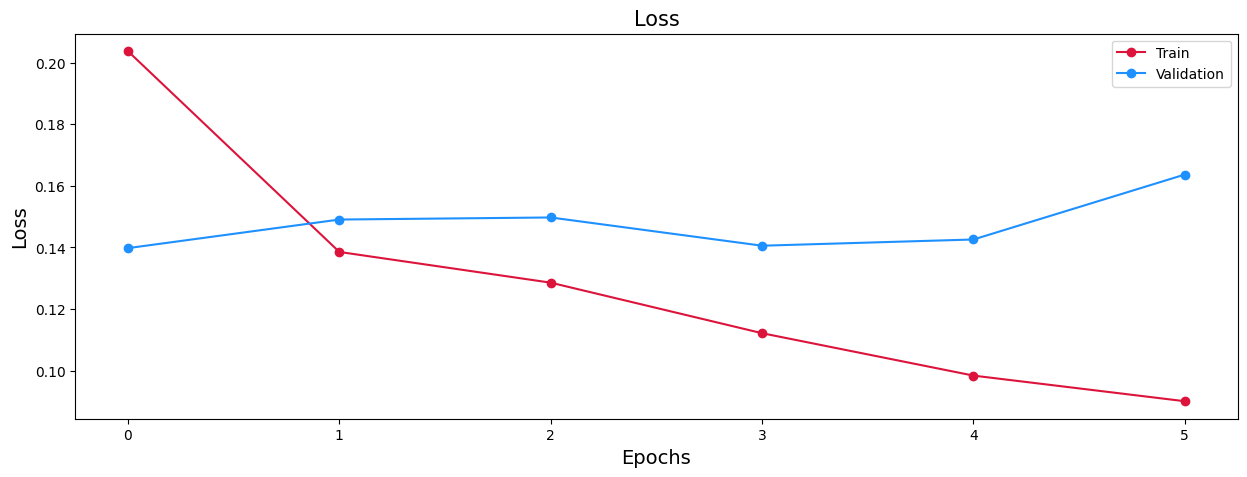

In [ ]:
fig = plt.figure(figsize=(15, 5))
plt.plot(history.history['loss'], linestyle='solid', marker='o', color='crimson', label='Train')
plt.plot(history.history['val_loss'], linestyle='solid', marker='o', color='dodgerblue', label='Validation')
plt.xlabel('Epochs', fontsize = 14)
plt.ylabel('Loss',fontsize=14)
plt.title('Loss', fontsize=15)
plt.legend(loc='best')
fig.savefig(f'{MODEL_PATH}/evaluation.png', bbox_inches='tight')
plt.show()

## Reload the model

In [ ]:
reloaded_model = create_model(optimizer)
reloaded_model.load_weights(f'{MODEL_PATH}/Visobert_no_preproceess.h5')
reloaded_model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFXLMRobertaModel: ['lm_head.dense.weight', 'lm_head.dense.bias', 'roberta.embeddings.position_ids', 'lm_head.layer_norm.weight', 'lm_head.layer_norm.bias', 'lm_head.bias']
- This IS expected if you are initializing TFXLMRobertaModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFXLMRobertaModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFXLMRobertaModel were not initialized from the PyTorch model and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

KerasTensor(type_spec=TensorSpec(shape=(None, 3072), dtype=tf.float32, name=None), name='tf.__operators__.getitem_2/strided_slice:0', description="created by layer 'tf.__operators__.getitem_2'")
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 attention_mask (InputLayer  [(None, 256)]                0         []                            
 )                                                                                                
                                                                                                  
 input_ids (InputLayer)      [(None, 256)]                0         []                            
                                                                                                  
 tfxlm_roberta_model_2 (TFX  TFBaseModelOutputWithPooli   9756595   ['attention_mask[0][0]',   

# Prediction

In [ ]:
y_test_argmax = np.argmax(y_test, axis=-1)
y_test_argmax

array([[0, 0, 0, ..., 0, 3, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 3, 0],
       ...,
       [0, 0, 1, ..., 1, 0, 0],
       [0, 0, 3, ..., 0, 0, 0],
       [0, 0, 0, ..., 2, 0, 0]])

## Predict on test data

In [ ]:
def predict(model, inputs, batch_size=1, verbose=0):
    y_pred = model.predict(inputs, batch_size=batch_size, verbose=verbose)
    y_pred = y_pred.reshape(len(y_pred), -1, 4)
    return np.argmax(y_pred, axis=-1) 

In [ ]:
def print_acsa_pred(replacements, categories, sentence_pred):
    sentiments = map(lambda x: replacements[x], sentence_pred)
    for category, sentiment in zip(categories, sentiments): 
        if sentiment: print(f'=> {category},{sentiment}')

In [ ]:
y_pred = predict(reloaded_model, test_tf_dataset, BATCH_SIZE, verbose=1)
reloaded_model.evaluate(test_tf_dataset, batch_size=BATCH_SIZE, verbose=1)

195/195 [==============================] - 48s 226ms/step - loss: 0.1605


0.16045603156089783

In [ ]:
replacements = {0: None, 1: 'positive', 2: 'negative', 3: 'neutral'}
categories = df_test.columns[1:]

print('Example:', df_test['Review'][1])
print_acsa_pred(replacements, categories, y_pred[1])

Example: Hàng về đẹp lắm nha ship thân thiện đi giày vừa in❤️
=> Shipping,positive
=> Outlook,positive
=> Size,positive


## Predict random text

In [ ]:
example_input = text_preprocess(input('Enter your sentence: '))
tokenized_input = tokenizer(example_input,max_length=256 ,padding='max_length', truncation=True)
features = {x: [[tokenized_input[x]]] for x in tokenizer.model_input_names}

pred = predict(reloaded_model, Dataset.from_tensor_slices(features))
print_acsa_pred(replacements, categories, pred[0])

# Report metrics

# Aspect score

In [ ]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for idx, i in enumerate(list_aspect):
    print(i)
    true = df_test[i].values
    pred = [row[idx] for row in y_pred]
    for i in range(len(pred)):
        if pred[i] == 0:
            pred[i] = -1
        elif pred[i] == 3:
            pred[i] = 2
        elif pred[i] == 2:
            pred[i] = 0
    print(classification_report(pred, true))

Price
              precision    recall  f1-score   support

          -1       0.98      0.97      0.97      2014
           0       0.00      0.00      0.00         0
           1       0.86      0.82      0.84       260
           2       0.42      0.58      0.48        66

    accuracy                           0.94      2340
   macro avg       0.56      0.59      0.57      2340
weighted avg       0.95      0.94      0.94      2340

Shipping
              precision    recall  f1-score   support

          -1       0.98      0.97      0.98      1640
           0       0.87      0.79      0.83       136
           1       0.96      0.94      0.95       564
           2       0.00      0.00      0.00         0

    accuracy                           0.95      2340
   macro avg       0.70      0.68      0.69      2340
weighted avg       0.97      0.95      0.96      2340

Outlook
              precision    recall  f1-score   support

          -1       0.94      0.88      0.91      113

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: Undefin

## Aspect Detection

In [ ]:
aspect_test = []
aspect_pred = []

for row_test, row_pred in zip(y_test_argmax, y_pred):
    for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
        aspect_test.append(bool(col_test) * categories[index])
        aspect_pred.append(bool(col_pred) * categories[index])

In [ ]:
aspect_report = classification_report(aspect_test, aspect_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_test, aspect_pred, digits=4, zero_division=1))

              precision    recall  f1-score   support

                 0.9434    0.9575    0.9504     14062
     General     0.7535    0.5678    0.6476       479
      Others     0.7240    0.8466    0.7805       189
     Outlook     0.9460    0.8961    0.9204      1271
       Price     0.8497    0.8123    0.8306       341
     Quality     0.7941    0.8265    0.8100       686
    Shipping     0.9457    0.9390    0.9423       705
Shop_Service     0.8641    0.7733    0.8162       600
        Size     0.8026    0.7984    0.8005       387

    accuracy                         0.9249     18720
   macro avg     0.8470    0.8242    0.8332     18720
weighted avg     0.9239    0.9249    0.9239     18720



## Polarity Detection

In [ ]:
y_test_flat = y_test_argmax.flatten()
y_pred_flat = y_pred.flatten()
target_names = list(map(str, replacements.values()))

In [ ]:
polarity_report = classification_report(y_test_flat, y_pred_flat, digits=4, output_dict=True)
print(classification_report(y_test_flat, y_pred_flat, target_names=target_names, digits=4))

              precision    recall  f1-score   support

        None     0.9434    0.9575    0.9504     14062
    positive     0.8275    0.8592    0.8431      3273
    negative     0.7311    0.5201    0.6078       596
     neutral     0.5431    0.4309    0.4806       789

    accuracy                         0.9042     18720
   macro avg     0.7613    0.6919    0.7205     18720
weighted avg     0.8995    0.9042    0.9009     18720



## Aspect + Polarity

In [ ]:
aspect_polarity_test = []
aspect_polarity_pred = []

for row_test, row_pred in zip(y_test_argmax, y_pred):
    for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
        aspect_polarity_test.append(f'{categories[index]},{replacements[col_test]}')
        aspect_polarity_pred.append(f'{categories[index]},{replacements[col_pred]}')

In [ ]:
aspect_polarity_test = [x for x in aspect_polarity_test if x != 'Others,None']
aspect_polarity_test = [x for x in aspect_polarity_test if x != 'Others,neutral']

aspect_polarity_pred = [x for x in aspect_polarity_pred if x != 'Others,None']
aspect_polarity_pred = [x for x in aspect_polarity_pred if x != 'Others,neutral']


In [ ]:
aspect_polarity_report = classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1))

                       precision    recall  f1-score   support

         General,None     0.8954    0.9522    0.9229      1861
     General,negative     1.0000    0.0909    0.1667        11
      General,neutral     0.7937    0.2732    0.4065       183
     General,positive     0.6094    0.6351    0.6220       285
         Outlook,None     0.8838    0.9392    0.9107      1069
     Outlook,negative     0.7333    0.4632    0.5677        95
      Outlook,neutral     0.4375    0.1207    0.1892        58
     Outlook,positive     0.9149    0.9231    0.9190      1118
           Price,None     0.9682    0.9755    0.9718      1999
       Price,negative     1.0000    0.0000    0.0000         3
        Price,neutral     0.5758    0.4176    0.4841        91
       Price,positive     0.8154    0.8583    0.8363       247
         Quality,None     0.9268    0.9111    0.9189      1654
     Quality,negative     0.6234    0.4898    0.5486        98
      Quality,neutral     0.4082    0.1818    0.2516  

## Summary

In [ ]:
aspect_dict = aspect_report['macro avg']
aspect_dict['accuracy'] = aspect_report['accuracy']

polarity_dict  = polarity_report['macro avg']
polarity_dict['accuracy'] = polarity_report['accuracy']

aspect_polarity_dict = aspect_polarity_report['macro avg']
aspect_polarity_dict['accuracy'] = aspect_polarity_report['accuracy']

In [ ]:
df_report = pd.DataFrame.from_dict([aspect_dict, polarity_dict, aspect_polarity_dict])
df_report.index = ['Aspect Detection', 'Polarity Detection', 'Aspect + Polarity']
df_report.drop('support', axis=1)

,precision,recall,f1-score,accuracy
Aspect Detection,0.847003,0.824185,0.833169,0.924893
Polarity Detection,0.761299,0.691921,0.720460,0.904167
Aspect + Polarity,0.772148,0.600060,0.616257,0.895971
